# Section I. Research

### Load libraries, functions, palette, theme

In [1]:
import os
from pathlib import Path

In [2]:
# load libraries and palette
%run __libraries.ipynb

In [3]:
# load functions
# from __functions import *
%run __functions.ipynb

In [4]:
# start stopwatch
start = stopwatch_start()

### Variables

In [5]:
dir_current = '01-explore'

In [6]:
dir_save_img = 'docs/img/' + dir_current

## Load Data

In [7]:
data_raw = pd.read_csv('data-raw/' + 'creditcard.csv')

In [8]:
data_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
data_raw.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [10]:
len(data_raw.columns)

31

In [11]:
data_raw.shape

(284807, 31)

In [12]:
data_raw['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
data_raw['Class'].mean()

0.001727485630620034

## Train Test Split

In [14]:
train_size = 0.7

In [15]:
train_last_ixd = math.floor(len(data_raw) * train_size)

In [16]:
train_last_ixd

199364

In [17]:
data_train = data_raw[:train_last_ixd].copy()

In [18]:
data_train.shape

(199364, 31)

In [19]:
data_test = data_raw[train_last_ixd:].copy()

In [20]:
data_test.shape

(85443, 31)

In [21]:
data_test.shape[0] / data_train.shape[0]

0.42857787765093

# Data Explore

In [22]:
data = data_train.copy()

In [23]:
data.shape

(199364, 31)

### Additional Variables and Datasets

##### Variables

In [24]:
target = 'Class'

In [25]:
features = (data
           .drop([target], axis=1)
           .select_dtypes(include=['int64', 'float64'])
           .columns.tolist())

In [26]:
len(features)

30

In [27]:
assert len(data.columns) == len(features) + 1

##### Datasets

In [28]:
cleans, frauds = update_cleans_and_frauds(data)

In [29]:
cleans_sample = cleans[::500].copy()

In [30]:
cleans_sample_random_ratio = 0.7

In [31]:
cleans_sample_random_length = math.floor(len(frauds)/cleans_sample_random_ratio)
cleans_sample_random = cleans.sample(n=cleans_sample_random_length)

#### Remove transations with 'Amount' == 0

### Features: Missing Values Handling

No NaN values

In [32]:
data_describe(data[features]).head(5)

,Type,Count,Unique,NaN,Percentages
Time,float64,199364,89844,0,0
V1,float64,199364,193582,0,0
V2,float64,199364,193582,0,0
V3,float64,199364,193582,0,0
V4,float64,199364,193582,0,0


## Time variable

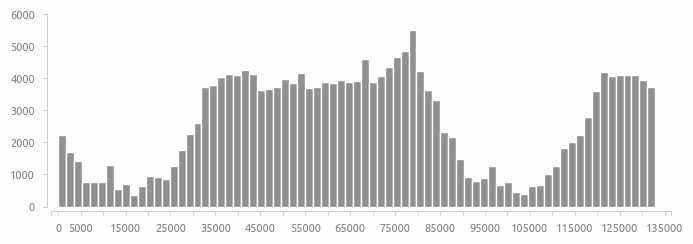

Image 'time_hist.png' successfully saved into 'docs/img/01-explore' directory


In [92]:
fig, ax = plt.subplots(figsize=(8, 2.5))

ax.hist(
    x=data['Time'],
    bins=75,
    color=palette[-2],
    **hist
)

ax.set_xticks(arange(0, 140000, 5000))
axis_add_interval_to_first_last_ticks(ax, scale=0.3, axis='x')

axis_rstyle(grid=False)

ticklabels = ax.xaxis.get_ticklabels()
for i, ticklabel in enumerate(ticklabels):
    if (i % 2 != 0) & (i != 1):
        ticklabel.set_visible(False)

plt.show()

savefig('time_hist', dir_save_img, format='png')

##### Transactions per time unit

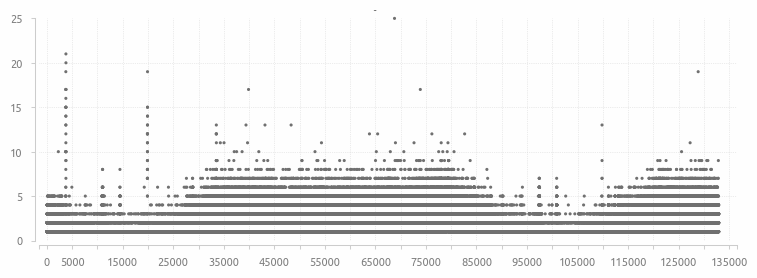

Image 'time_scatter.png' successfully saved into 'docs/img/01-explore' directory


In [34]:
fig, ax = plt.subplots()

ax.scatter(
    data['Time'].value_counts().index,
    data['Time'].value_counts(),
    edgecolors='none',
    color=palette[-3],
    s=5,
    **scatter
)

ax.set_xticks(arange(0, 140000, 5000))
ax.set_yticks(arange(0, 30, 5))

axis_add_interval_to_first_last_ticks(ax, scale=0.3, axis='x')
axis_rstyle(grid=True)

ax.set_ylabel(None)
ax.set_xlabel(None)

ticklabels = ax.xaxis.get_ticklabels()
for i, ticklabel in enumerate(ticklabels):
    if (i % 2 != 0) & (i != 1):
        ticklabel.set_visible(False)

plt.show()

savefig('time_scatter', dir_save_img, format='png')

#### Time variables formatted

Assumption: minimum transactions is around 0:00 hours.  
Assumption: 14400 time units equivalents 0:00 hours

##### <font color='#CE4F44'>Variable:</font> TimeSecondOfDay

In [35]:
data['TimeSecondOfDay'] = data['Time'].copy()

In [36]:
data['TimeSecondOfDay'] -= 14400

In [37]:
data['TimeSecondOfDay'] = data['TimeSecondOfDay'].apply(lambda x: time_variable_transform(x, 0, 86400))

##### <font color='#CE4F44'>Variable:</font> TimeTimestamp

In [38]:
timestamp_delta = data['TimeSecondOfDay'].iloc[0]

In [39]:
timestamp_delta

72000.0

In [40]:
data['TimeTimestamp'] = data['Time'].copy()
data['TimeTimestamp'] += timestamp_delta

##### <font color='#CE4F44'>Variable:</font> TimeDatetime

In [41]:
data['TimeDatetime'] = pd.to_datetime(data['TimeTimestamp'], unit='s')
data['TimeDatetime'] = data['TimeDatetime'].apply(lambda x: x.replace(year=2024, month=6) + dt.timedelta(days=5))

##### <font color='#CE4F44'>Variable:</font> TimeMinute, TimeHour

In [42]:
data['TimeMinute'] = data['TimeDatetime'].dt.minute

In [43]:
data['TimeHour'] = data['TimeDatetime'].dt.hour

##### <font color='#CE4F44'>Variable:</font> TransactionNight

In [44]:
transactions_at_night_mask = (
    (data['TimeHour'].between(0,7)) | (data['TimeHour'].between(19,23))
)

In [45]:
data['TransactionNight'] = np.where(transactions_at_night_mask, 1, 0)

##### <font color='#1E82C8'>Update:</font> Cleans and Frauds

In [46]:
cleans, frauds = update_cleans_and_frauds(data)

#### Balance

In [47]:
df_balance_create(data, target, scale=6)

Total: 199364 

Positive: 384 (0.001926%)
Negative: 198980 (0.998074%) 

Positive / Negative: 0.00


## Target variable

#### Total transactions and total frauds

In [48]:
data_target_by_hour_seq = data.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count().reset_index()
data_target_by_hour_seq_smoothed = smoothed(data_target_by_hour_seq)

In [49]:
frauds_target_by_hour_seq = frauds.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count().reset_index()
frauds_target_by_hour_seq_smoothed = smoothed(frauds_target_by_hour_seq)

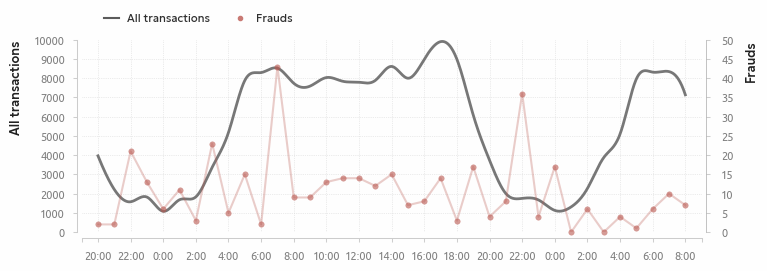

Image 'transactions_overview_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [91]:
fig, ax1 = plt.subplots(figsize=(8, 2.5))

ax1.plot(
    data_target_by_hour_seq_smoothed.index,
    data_target_by_hour_seq_smoothed['Class'],
    linewidth=2,
    color=palette[-3],
    alpha=0.95
)

ax1.set_xticks(
    ticks=arange(len(data_target_by_hour_seq['TimeDatetime']))[::2],
    labels=data_target_by_hour_seq['TimeDatetime'].dt.hour[::2]
)

ax2 = ax1.twinx()

ax2.plot(
    frauds_target_by_hour_seq.index,
    frauds_target_by_hour_seq['Class'],
    # linewidth=1,
    color=palette[1],
    alpha=0.3
)

ax2.scatter(
    x=frauds_target_by_hour_seq.index,
    y=frauds_target_by_hour_seq['Class'],
    color=palette[1],
    alpha=0.6,
    clip_on=False,
    **scatter
)

xticklabels = ax1.get_xticklabels()
xticklabels = [i.get_text()+':00' for i in xticklabels]
ax1.set_xticklabels((xticklabels))

ax1.set_ylim(0, 10000)
ax1.set_yticks(arange(0, 10000, 1000, True))

ax2.set_ylim(0, 50)
ax2.set_yticks(arange(0, 50, 5, True))

ax1.set_ylabel('All transactions', **label)
ax2.set_ylabel('Frauds', **label)

axis_add_interval_to_first_last_ticks(ax1, scale=0.5, axis='x')
axis_rstyle(
    offset_bottom=4,
    grid=True,
    ax=ax1
)

ax2.grid(False)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_position(('outward', 3))
ax2.tick_params(
    axis='y',
    direction='out',
    color='#CECECE',
    labelcolor='#808080',
    size=3
)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.02, 1.03)),
    **legend_create_handles(
        2, ['l', 'p'],
        labels=['All transactions', 'Frauds'],
        colors=[palette[0], alpha_color(palette[1], 0.8)],
    ),
    **legend
)

plt.show()

savefig('transactions_overview_per_hour', dir_save_img, format='png')

#### Additional Variable : Fraud per transaction by hours

##### <font color='#CE4F44'>Variable:</font> FraudPerHundredTransactionByHour

In [51]:
def calculate_fraud_per_transaction(x):
    
    length_clean = len(x.loc[x[target] == 0])
    length_fraud = len(x.loc[x[target]==1])
    
    return 100 * length_fraud / length_clean

In [52]:
fraud_per_hundred_tr_by_hour_map = data.groupby('TimeHour').apply(calculate_fraud_per_transaction)

In [53]:
data['FraudPerHundredTransactionByHour'] = data['TimeHour'].map(fraud_per_hundred_tr_by_hour_map)

##### <font color='#1E82C8'>Update:</font> Cleans and Frauds

In [54]:
cleans, frauds = update_cleans_and_frauds(data)

In [55]:
data_frauds_per_hundred_hour_plot = data[['TimeHour', 'FraudPerHundredTransactionByHour']].drop_duplicates()
data_frauds_per_hundred_hour_plot = data_frauds_per_hundred_hour_plot.sort_values('TimeHour').reset_index()
data_frauds_per_hundred_hour_plot_smoothed = smoothed(data_frauds_per_hundred_hour_plot, n=300, k=2)

In [56]:
hours_night = data.loc[data['TransactionNight']==1, 'TimeHour'].unique()
hours_day = data.loc[data['TransactionNight']==0, 'TimeHour'].unique()

In [57]:
day_values = data_frauds_per_hundred_hour_plot.loc[
    data_frauds_per_hundred_hour_plot['TimeHour'].isin(hours_day),
    'FraudPerHundredTransactionByHour'
]

night_values = data_frauds_per_hundred_hour_plot.loc[
    data_frauds_per_hundred_hour_plot['TimeHour'].isin(hours_night),
    'FraudPerHundredTransactionByHour'
]

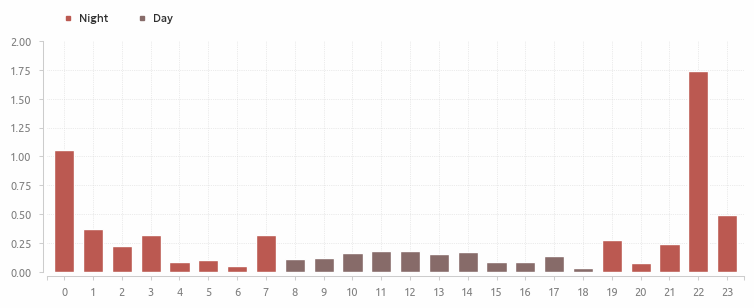

Image 'transactions_fraud_per_100_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [88]:
day_color = '#876B69'

fig, ax = plt.subplots()

ax.bar(
    x=night_values.index,
    height=night_values,
    color=palette[1],
    width=0.7
)

ax.bar(
    x=day_values.index,
    height=day_values,
    color=day_color,
    width=0.7
)

ax.set_xticks(
    data_frauds_per_hundred_hour_plot['TimeHour']
)

axis_add_interval_to_first_last_ticks(ax, scale=0.6, axis='x')
axis_rstyle(grid=True)

ax.tick_params(
    # bottom=False,
    pad=5
)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0, 1.03)),
    **legend_create_handles(
        2, ['s', 's'],
        alphas=[1, 1],
        labels=['Night', 'Day'],
        colors=[palette[1], day_color],
    ),
    **legend
)

# ax.set_ylabel('Frauds per 100 transactions', **label)
ax.set_xlabel(None)

plt.show()

savefig('transactions_fraud_per_100_by_hour', dir_save_img, format='png')

#### Significance of night and day fraud frequencies

Difference in proportions significant (p-value = 0).

In [59]:
frauds_night = data.loc[data['TransactionNight']==1, target].values

In [60]:
frauds_day = data.loc[data['TransactionNight']==0, target].values

In [61]:
chi2_test_table = np.array([
    [len(frauds_night[frauds_night==1]), len(frauds_night)],
    [len(frauds_day[frauds_day==1]), len(frauds_day)]
])

In [62]:
chi2_test_table

array([[   259, 100928],
       [   125,  98436]])

In [63]:
chi2_results = chi2_contingency(chi2_test_table)

In [64]:
chi2_results.pvalue

6.303450851417631e-11

In [65]:
chi2_results.pvalue < 0.0001

True

#### Resampling

In [66]:
%%time
samples_bootstrap = get_cleans_sample_w_ci(
    df=cleans,
    length=len(frauds),
    n=1000
)

CPU times: user 16.8 s, sys: 416 ms, total: 17.2 s
Wall time: 18.3 s


In [67]:
samples_bootstrap = samples_bootstrap.reset_index(names='TimeDatetime')

In [68]:
samples_bootstrap_smoothed = smoothed(samples_bootstrap)

In [69]:
frauds_by_hour = frauds.groupby(pd.Grouper(key='TimeDatetime', freq='h'))[target].count().reset_index()

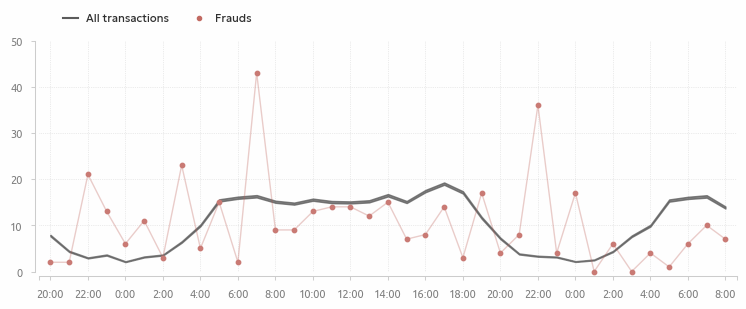

Image 'transactions_simulation_count_per_hour.png' successfully saved into 'docs/img/01-explore' directory


In [70]:
fig, ax = plt.subplots()

ax.fill_between(
    x=samples_bootstrap.index,
    y1=samples_bootstrap['ci_min'],
    y2=samples_bootstrap['ci_max'],
    color=palette[0],
    # edgecolor='none',
    alpha=0.75
)

sns.lineplot(
    x=frauds_by_hour.index,
    y=frauds_by_hour['Class'],
    linewidth=1,
    color=palette[1],
    alpha=0.3,
    zorder=1
)

plt.scatter(
    x=frauds_by_hour.index,
    y=frauds_by_hour['Class'],
    color=alpha_color(palette[1], 0.8),
    s=10,
    zorder=2,
    clip_on=False,
    # **scatter
)

ax.set_yticks(arange(0, 50, 10, True))
ax.set_xticks(
    ticks=arange(len(samples_bootstrap['TimeDatetime']))[::2],
    labels=samples_bootstrap['TimeDatetime'].dt.hour[::2]
)

xticklabels = ax.get_xticklabels()
xticklabels = [i.get_text()+':00' for i in xticklabels]
ax.set_xticklabels((xticklabels))

ax.set_xlabel(None)
ax.set_ylabel(None)

axis_add_interval_to_first_last_ticks(ax, scale=0.3, axis='x')
axis_rstyle(grid=True)

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0.02, 1.03)),
    **legend_create_handles(
        2, ['l', 'p'],
        labels=['All transactions', 'Frauds'],
        colors=[palette[0], alpha_color(palette[1], 0.9)],
    ),
    **legend
)

plt.show()

savefig('transactions_simulation_count_per_hour', dir_save_img, format='png')

In [71]:
%time
bootstrap_fraud_prob = get_cleans_sample_for_probability(
    df=cleans, 
    length=len(frauds),
    n=1000
)

CPU times: user 4 μs, sys: 2 μs, total: 6 μs
Wall time: 10 μs


In [72]:
bootstrap_fraud_prob_smoothed = smoothed(bootstrap_fraud_prob, k=3, n=300)

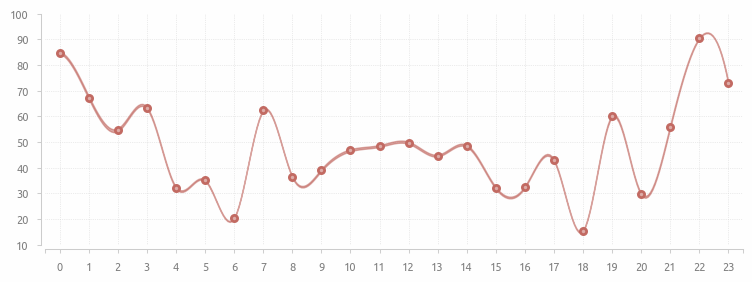

Image 'transactions_simulation_probability_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [87]:
fig, ax = plt.subplots()

ax.fill_between(
    x=bootstrap_fraud_prob_smoothed.index,
    y1=bootstrap_fraud_prob_smoothed['ci_min'],
    y2=bootstrap_fraud_prob_smoothed['ci_max'],
    color=alpha_color(palette[1], 1),
    edgecolor=alpha_color(palette[1], 1),
    # edgecolor='none',
    alpha=0.5
)

ax.scatter(
    x=bootstrap_fraud_prob.index,
    y=bootstrap_fraud_prob['statistic'],
    linewidths=2,
    edgecolor=alpha_color(palette[1], 0.9),
    color=alpha_color(palette[1], 0.5),
    s=20
)

ax.set_xlabel(None)
# ax.set_ylabel('Hypothetical probability of fraud', **label)

ax.set_xticks(bootstrap_fraud_prob.index)

axis_add_interval_to_first_last_ticks(ax, scale=0.5, axis='x')
axis_rstyle()

# percents instead of proportions
ax.yaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(xmax=1.0, symbol='')
)

plt.show()

savefig('transactions_simulation_probability_by_hour', dir_save_img, format='png')

## Amounts variable

#### Median by hour

##### Trend

In [74]:
amount_median_freq_per_hour = data.groupby(pd.Grouper(key='TimeDatetime', freq='h'))['Amount'].median()
amount_median_freq_per_hour_smoothed = smoothed(amount_median_freq_per_hour, datetime_index=True)

Image 'amount_median_per_hour.png' successfully saved into 'docs/img/01-explore' directory


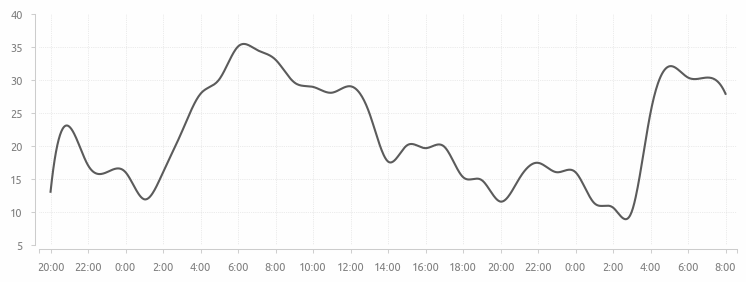

In [75]:
ax = ax_current()

ax.plot(
    amount_median_freq_per_hour_smoothed.index,
    amount_median_freq_per_hour_smoothed['Amount'],
    # linewidth=1.5
)

ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H'))
ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))

axis_add_interval_to_first_last_ticks(ax, scale=0.3, axis='x')
axis_rstyle()
axis_ticklabels_add_symbols(':00', avoid_first_last=True)

savefig('amount_median_per_hour', dir_save_img, format='png')

##### <font color='#CE4F44'>Variable:</font> AmountMedianByHour

In [76]:
data['AmountMedianByHour'] = data.groupby('TimeHour')['Amount'].transform('median')

##### <font color='#1E82C8'>Update:</font> Cleans and Frauds

In [77]:
cleans, frauds = update_cleans_and_frauds(data)

##### Variable visualization

In [78]:
amount_median_by_hour_vis = data.groupby('TimeHour')['Amount'].median()

In [79]:
amount_median_by_hour_vis.head()

TimeHour
0    15.950
1    11.850
2    11.850
3    15.000
4    25.955
Name: Amount, dtype: float64

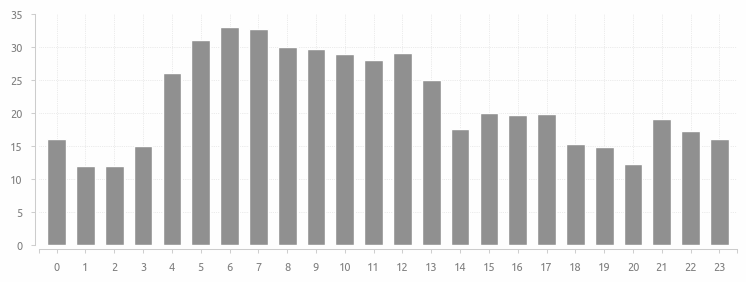

Image 'amount_median_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [86]:
fig, ax = plt.subplots()

ax.bar(
    x=amount_median_by_hour_vis.index,
    height=amount_median_by_hour_vis,
    width=0.65,
    color=palette[-2]
    # linewidth=1.5
)

ax.set_xticks(
    amount_median_by_hour_vis.index,
    amount_median_by_hour_vis.index
)

axis_add_interval_to_first_last_ticks(ax, scale=0.6, axis='x')
axis_rstyle()

plt.show()

savefig('amount_median_by_hour', dir_save_img, format='png')

In [81]:
cleans_amount_median_by_hour_vis = cleans.groupby('TimeHour')['Amount'].median()
frauds_amount_median_by_hour_vis = frauds.groupby('TimeHour')['Amount'].median()

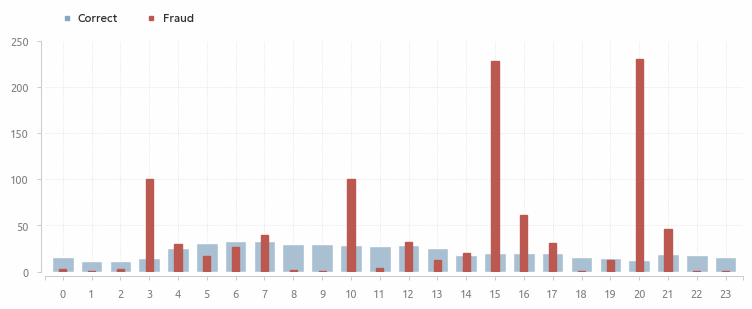

Image 'amount_median_frauds_by_hour.png' successfully saved into 'docs/img/01-explore' directory


In [82]:
fig, ax = plt.subplots()

ax.bar(
    x=cleans_amount_median_by_hour_vis.index,
    height=cleans_amount_median_by_hour_vis,
    width=0.75,
    color=alpha_color(palette[2], 0.5)
)

ax.bar(
    x=frauds_amount_median_by_hour_vis.index,
    height=frauds_amount_median_by_hour_vis,
    width=0.25,
    edgecolor=palette[1],
    color=palette[1]
)

ax.set_xticks(
    amount_median_by_hour_vis.index,
    amount_median_by_hour_vis.index
)

axis_add_interval_to_first_last_ticks(ax, scale=0.6, axis='x')
axis_rstyle()

leg = plt.legend(
    **legend_inline(bbox_to_anchor=(0, 1.03)),
    **legend_create_handles(
        2, ['s', 's'],
        alphas=[1, 1],
        labels=['Correct', 'Fraud'],
        colors=[alpha_color(palette[2], 0.7), palette[1]],
    ),
    **legend
)

plt.show()

savefig('amount_median_frauds_by_hour', dir_save_img, format='png')

##### <font color='#CE4F44'>Variable:</font> AmountFracByMedianByHour

In [83]:
data['AmountFracByMedianByHour'] = data['Amount'] / data['AmountMedianByHour']

##### <font color='#1E82C8'>Update:</font> Cleans and Frauds

In [84]:
cleans, frauds = update_cleans_and_frauds(data)

#### Count by hour

In [453]:
amount_count_per_hour = data.groupby(pd.Grouper(key='TimeDatetime', freq='h'))['Amount'].count()
amount_count_per_hour_smoothed = smoothed(amount_count_per_hour, datetime_index=True)

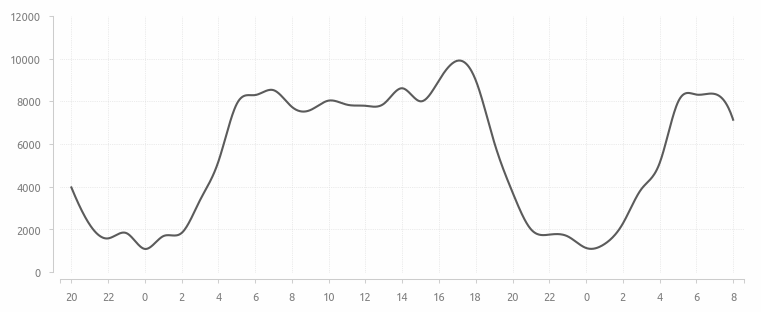

In [454]:
ax = ax_current()

ax.plot(
    amount_count_per_hour_smoothed.index,
    amount_count_per_hour_smoothed['Amount']
)

ax.xaxis.set_major_formatter(mpl.dates.DateFormatter(fmt='%-H'))
ax.xaxis.set_major_locator(mpl.dates.HourLocator(interval=2))

axis_add_interval_to_first_last_ticks(ax, scale=0.3, axis='x')

axis_rstyle(
    offset_left=0,
    offset_bottom=0,
    grid=True
)

#### Mean and median by target

In [455]:
cleans['Amount'].mean()

89.7154691928837

In [456]:
cleans['Amount'].median()

23.0

In [457]:
frauds['Amount'].mean()

118.64945312499998

In [458]:
frauds['Amount'].median()

11.855

#### Integer amounts

In [536]:
data['AmountInteger'] = (data['Amount'] % 1 == 0).astype(int)

In [550]:
data.loc[data['AmountInteger']==0, 'Class'].count()

148733

In [551]:
data.loc[data['AmountInteger']==1, 'Class'].count()

50631

<Axes: >

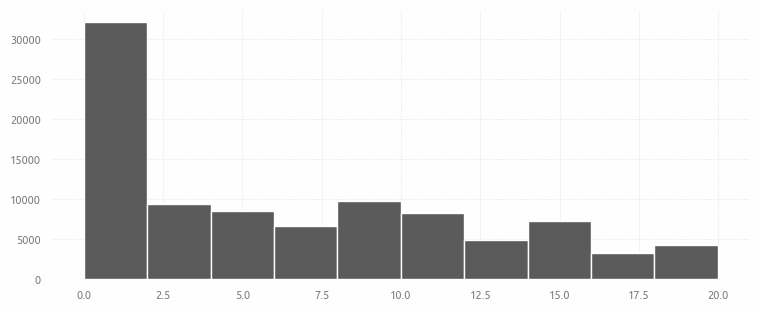

In [459]:
cleans.loc[cleans['Amount'] < 20, 'Amount'].hist()

<Axes: ylabel='Amount'>

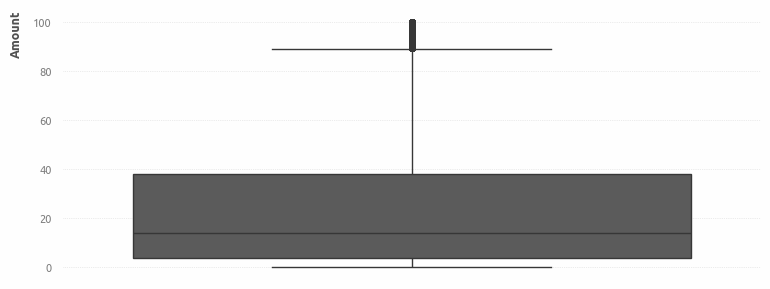

In [460]:
sns.boxplot(
    data=cleans[cleans['Amount']<100],
    y='Amount'
)

In [471]:
cleans_amount_count = cleans['Amount'].value_counts().reset_index().sort_values('count')

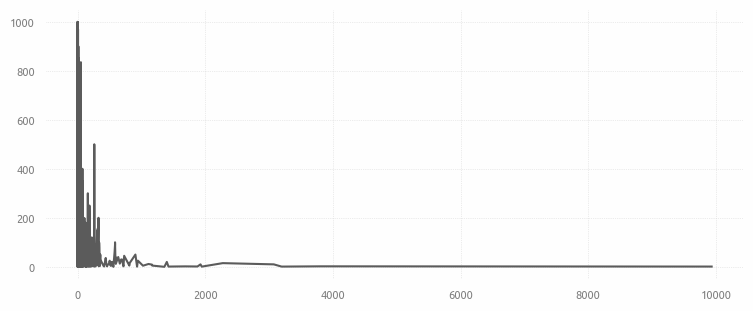

In [476]:
plt.plot(
    cleans_amount_count.loc[cleans_amount_count['Amount']<1000, 'count'],
    cleans_amount_count.loc[cleans_amount_count['Amount']<1000, 'Amount'],
)

In [477]:
cleans['Amount'].median()

23.0

In [486]:
conditions = [
    (data['Amount'] <= 1),
    (data['Amount'] > 1),
]

values = [
    0,
    1
]

In [492]:
data['AmountGroup'] = np.select(conditions, values)

In [494]:
data[['Amount', 'AmountGroup']]

,Amount,AmountGroup
0,149.62,1
1,2.69,1
2,378.66,1
3,123.50,1
4,69.99,1
...,...,...
199359,25.00,1
199360,40.46,1
199361,22.00,1
199362,1745.40,1


In [495]:
data['AmountGroup'].mean()

0.8932204410023876

In [474]:
cleans_amount_count

,Amount,count
27567,782.67,1
27557,237.11,1
27574,1291.77,1
27555,119.83,1
20518,84.58,1
...,...,...
4,15.00,2275
3,9.99,3075
2,0.89,3197
1,1.98,3818


<Axes: xlabel='Amount', ylabel='Count'>

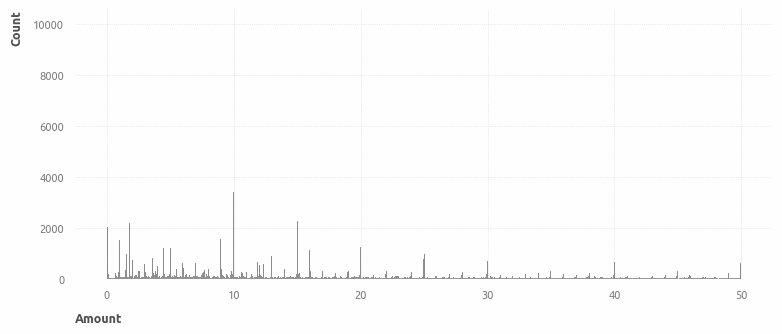

In [507]:
sns.histplot(
    data.loc[data['Amount'] < 50, 'Amount'],
    bins=1000
)

In [483]:
np.log(100)

4.605170185988092

<Axes: xlabel='Amount', ylabel='Count'>

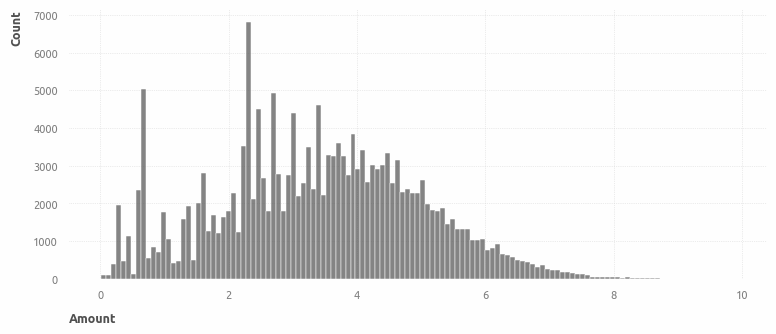

In [496]:
sns.histplot(np.log(data.loc[data['AmountGroup']==1, 'Amount']))

<Axes: xlabel='Amount', ylabel='Count'>

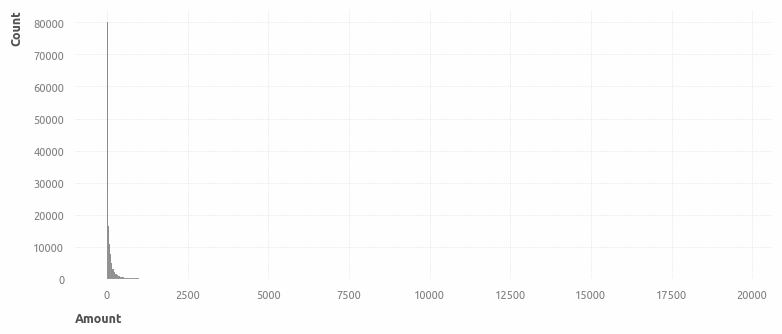

In [498]:
sns.histplot(data.loc[data['AmountGroup']==1, 'Amount'])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Amount', ylabel='Count'>

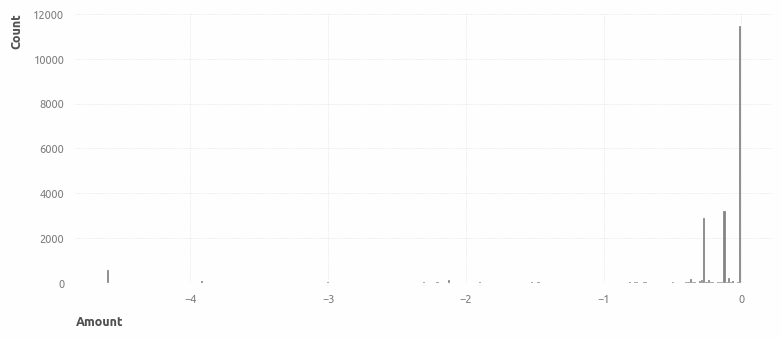

In [497]:
sns.histplot(np.log(data.loc[data['AmountGroup']==0, 'Amount']))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Amount', ylabel='Count'>

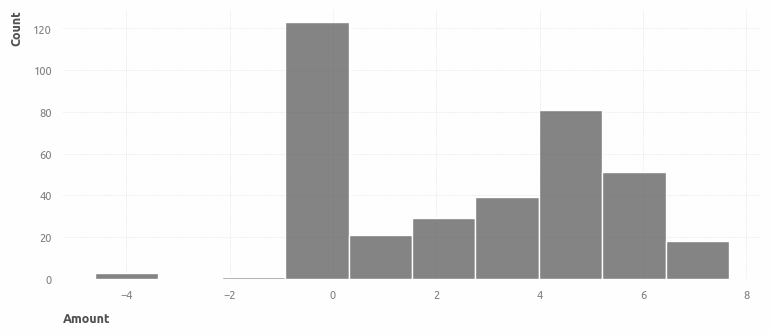

In [224]:
sns.histplot(np.log(frauds['Amount']))

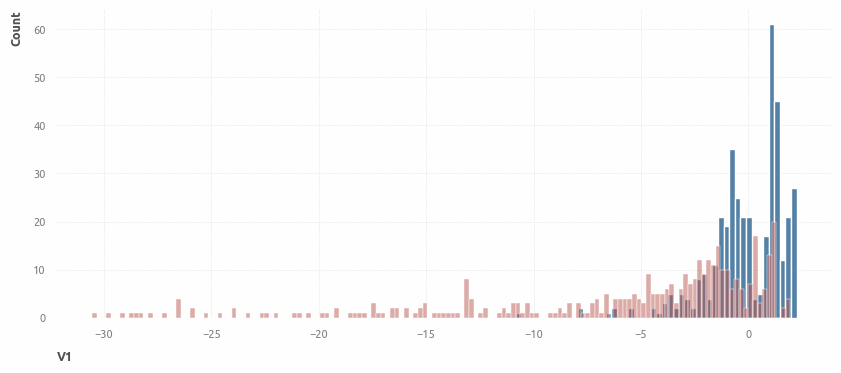

In [65]:
plt.figure(figsize=(10,4))

sns.histplot(
    data=cleans_sample['V1'],
    bins=50,
    alpha=1
)

sns.histplot(
    data=frauds['V1'],
    bins=150,
    color=palette[1],
    alpha=0.5
)

plt.show()

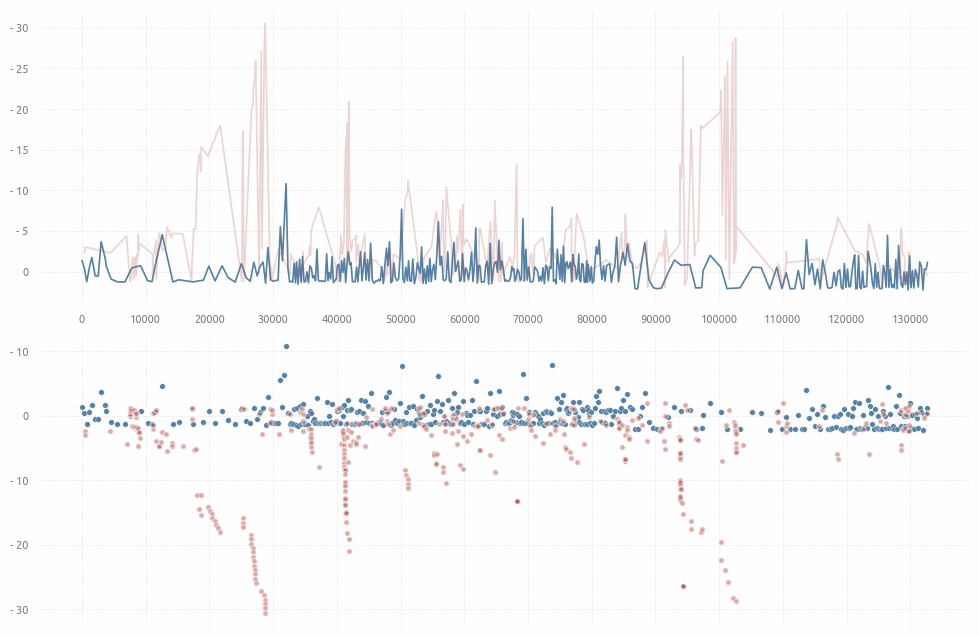

In [66]:
fig, axs = plt.subplots(2,1, figsize=(12,8))

axs[0].plot(
    cleans_sample['Time'],
    -cleans_sample['V1'],
)

axs[0].plot(
    frauds['Time'],
    -frauds['V1'],
    color=palette[1],
    alpha=0.25
)

axs[1].scatter(
    cleans_sample['Time'],
    -cleans_sample['V1'],
    # s=60,
    alpha=1,
    **scatter
)

axs[1].scatter(
    data=frauds,
    x='Time',
    y='V1',
    # s=50,
    alpha=0.5
)

# axs[0].set_yticks(ticks=cleans_sample['V1'])
axs[0].set_xticks(ticks=arange(0, frauds['Time'].max(), 10000))
axs[1].set_xticks(ticks=arange(0, frauds['Time'].max(), 10000))
axs[1].tick_params(labelbottom=False)
plt.subplots_adjust(hspace=0.1)

def change_sign(x, pos):
    if x != 0:
        return f'- {x:.0f}'
    else:
        return int(x)

def nochange_sign(x, pos):
    if x != 0:
        return f'- {abs(x):.0f}'
    else:
        return int(x)
    
axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(change_sign))
axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(nochange_sign))

plt.show()

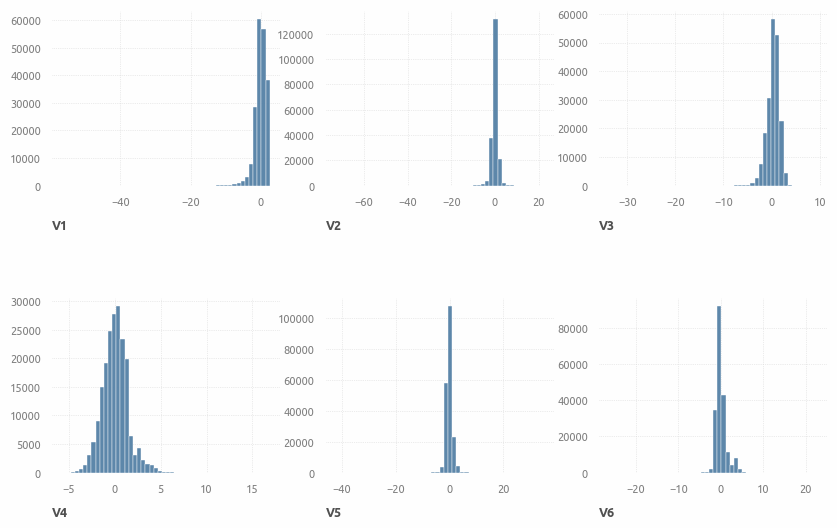

In [30]:
f = plot_gridplot(
    data=data.iloc[:, 1:7],
    features=data.iloc[:, 1:7].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

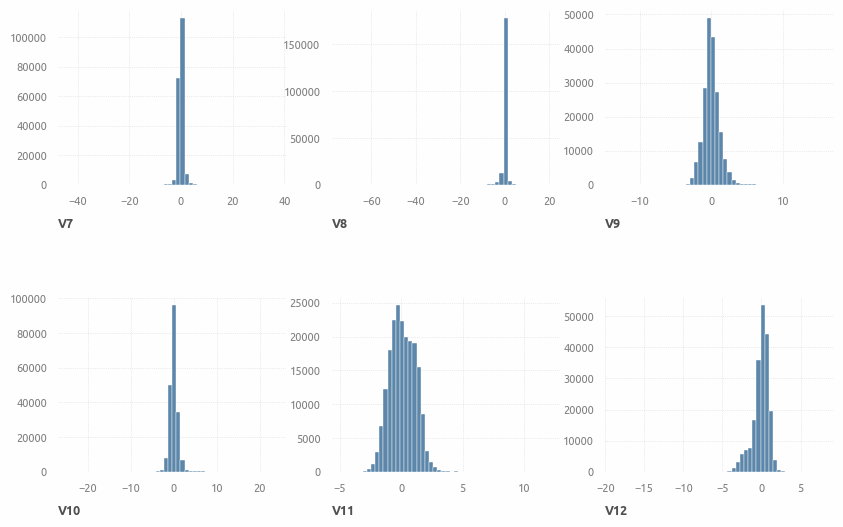

In [31]:
f = plot_gridplot(
    data=data.iloc[:, 7:13],
    features=data.iloc[:, 7:13].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

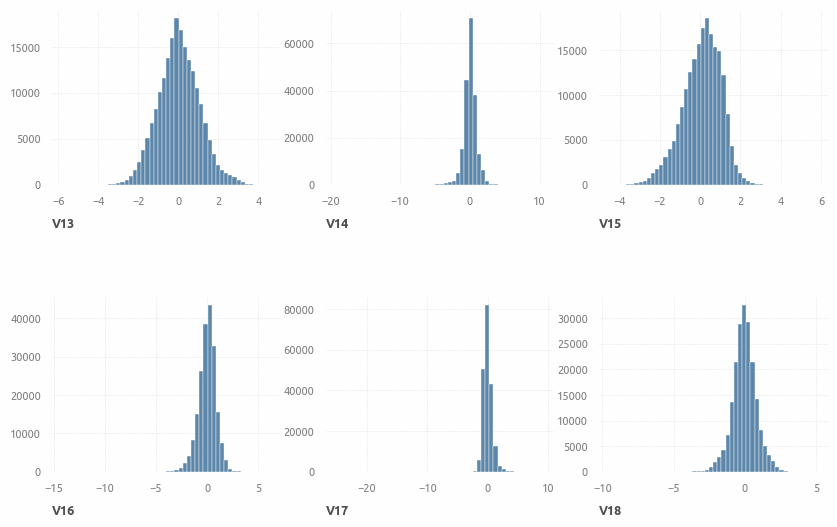

In [32]:
f = plot_gridplot(
    data=data.iloc[:, 13:19],
    features=data.iloc[:, 13:19].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

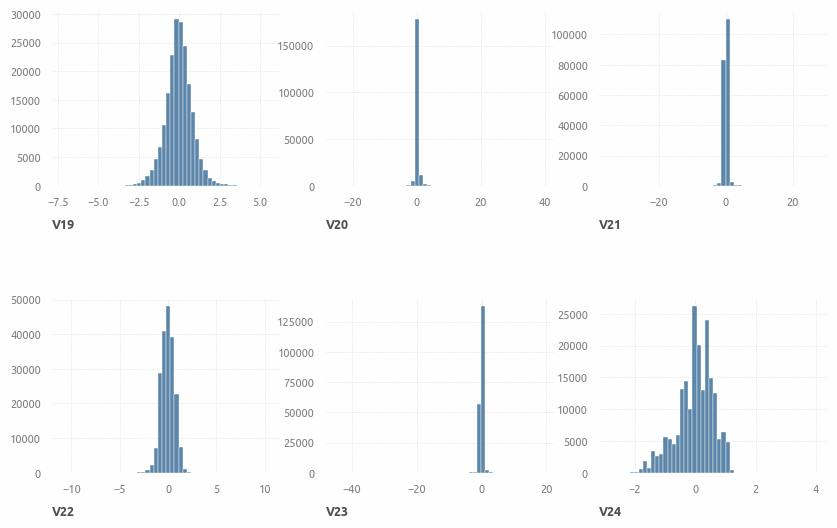

In [33]:
f = plot_gridplot(
    data=data.iloc[:, 19:25],
    features=data.iloc[:, 19:25].columns,
    figsize=(10,6),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

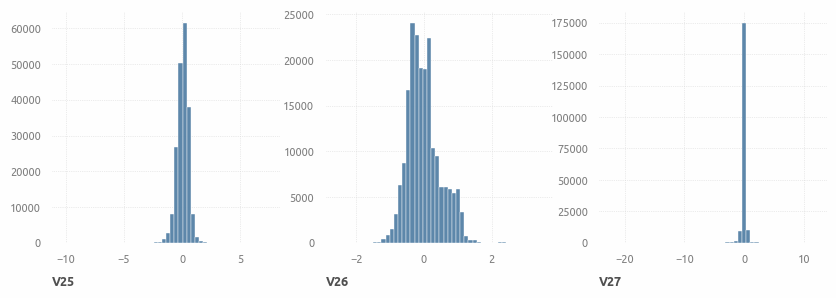

In [34]:
f = plot_gridplot(
    data=data.iloc[:, 25:28],
    features=data.iloc[:, 25:28].columns,
    figsize=(10,3),
    ncols=3,
    kind='hist',
    plot_shape='rectangle',
    hscale=1.6,
    histplot_kwargs={'bins': 50})

### Execution time

In [121]:
stopwatch_stop(start)

Execution time: 0:03:35
